# SisFall — AFD-CNN Training Notebook (Peak-Centred Windows, Balanced Classes)

Same model and preprocessing as `SisFall_train_peak.ipynb`, but **classes are balanced**:

**Fall class** (label 0): one max-peak window per recording (same as the original notebook).

**Non-fall / ADL classes**: multi-peak extraction per recording.  After the global-maximum window is extracted, its region is suppressed and the next highest peak is found.  This repeats until the recording is exhausted.  All candidate windows across all recordings are then sorted by peak magnitude and the top **TARGET_COUNT** windows are kept — where *TARGET_COUNT* equals the fall-class count so every class has the same number of samples.

Windowing steps (same as original):
1. Downsample 200 Hz → 100 Hz.
2. Compute ‖a‖ = √(ax² + ay² + az²) on ADXL345 raw ADC values.
3. Find each peak index of ‖a‖.
4. Extract a 2 s window (200 samples @ 100 Hz) **centred on that peak** (clamped to boundaries).
5. Normalise ADXL345 values to [0, 255].

Checkpoint is saved to `model/sisfall_peak_balanced_model.ckpt`.

**Input format (repeat-acc variant):** 1200 values = 600 ADXL345 values repeated twice.

**SisFall activity → class mapping:**

| SisFall codes | Class label | Activity |
|---|---|---|
| F01–F15 | 0 | **Fall** |
| D01, D02 | 2 | Walk |
| D03, D04 | 3 | Jog |
| D19 | 4 | Jump |
| D05 | 5 | Up-stairs |
| D06 | 6 | Down-stairs |
| D07, D08 | 7 | Stand→Sit |
| D09, D10 | 9 | Sit→Stand |

## 1. Setup

In [17]:
import sys, os
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)

import importlib, cnn as cnn_module
importlib.reload(cnn_module)

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.4.4


## 2. Configuration

In [18]:
SISFALL_PATH    = 'SisFall_dataset'
MODEL_SAVE_PATH = 'model/sisfall_peak_balanced_model.ckpt'
TRAIN_CSV       = 'data/sisfall_peak_balanced_train.csv'
TEST_CSV        = 'data/sisfall_peak_balanced_test.csv'

CLASS_LIST  = [0, 2, 3, 4, 5, 6, 7, 9]
CLASS_NUM   = len(CLASS_LIST)
CLASS_NAMES = {
    0: 'Fall', 2: 'Walk', 3: 'Jog', 4: 'Jump',
    5: 'Up-stairs', 6: 'Down-stairs', 7: 'Stand\u2192Sit', 9: 'Sit\u2192Stand'
}

# SisFall activity code → class label
CODE_TO_LABEL = {
    **{f'F{i:02d}': 0 for i in range(1, 16)},  # F01-F15 → Fall
    'D01': 2, 'D02': 2,   # Walk
    'D03': 3, 'D04': 3,   # Jog
    'D19': 4,             # Jump
    'D05': 5,             # Up-stairs
    'D06': 6,             # Down-stairs
    'D07': 7, 'D08': 7,  # Stand→Sit
    'D09': 9, 'D10': 9,  # Sit→Stand
}

WINDOW      = 200   # samples per window at 100 Hz = 2 s
HALF_WINDOW = WINDOW // 2

# Target samples per class: will be set to the actual fall count after
# collection (nominally 298).  Can be overridden here.
TARGET_COUNT = 298

print('Classes:', CLASS_LIST)
print('Activity codes tracked:', sorted(CODE_TO_LABEL.keys()))
print(f'Target samples per class: {TARGET_COUNT}')

Classes: [0, 2, 3, 4, 5, 6, 7, 9]
Activity codes tracked: ['D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08', 'D09', 'D10', 'D19', 'F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15']
Target samples per class: 298


## 3. Parse SisFall and Extract Peak-Centred Windows

Each `.txt` file has 9 columns at 200 Hz:
- Cols 0–2: **ADXL345** accelerometer (13-bit, ±16 g) — *used here*
- Cols 3–5: ITG-3200 gyroscope
- Cols 6–8: MMA8451Q accelerometer

**Fall recordings:** one window per recording (global-maximum peak).

**Non-fall recordings:** `extract_all_peaks` is used.  After extracting the max-peak window, that window region is zeroed in the magnitude signal and the process repeats, yielding a ranked list of non-overlapping peak windows per recording.  All candidates are pooled and sorted by peak magnitude.

**Balancing strategy (per ADL class):**
- If candidates ≥ TARGET: keep the top TARGET windows (highest peak magnitude).
- If candidates < TARGET: keep all, then **randomly oversample with replacement** until exactly TARGET windows are reached.

This guarantees every class (Fall and each ADL) has exactly the same number of samples.

In [19]:
def parse_sisfall_txt(filepath):
    """Read a SisFall .txt file → float32 array (N, 9) of raw ADC values."""
    rows = []
    with open(filepath) as f:
        for line in f:
            line = line.strip().rstrip(';')
            if not line:
                continue
            try:
                parts = [int(x.strip()) for x in line.split(',')]
                if len(parts) == 9:
                    rows.append(parts)
            except ValueError:
                pass
    return np.array(rows, dtype=np.float32) if rows else None


def normalize_adxl345(raw):
    """Map ADXL345 13-bit ADC values in [-4096, 4095] linearly to [0, 255]."""
    return np.clip((raw + 4096.0) / 8192.0 * 255.0, 0.0, 255.0)


def extract_peak_window(arr, window=200):
    """
    Return a single (window, 3) slice from arr (T, 3) centred on the sample
    with the highest vector magnitude.  Returns (None, None) if too short.
    """
    n = len(arr)
    if n < window:
        return None, None
    magnitude = np.linalg.norm(arr, axis=1)
    peak_idx  = int(np.argmax(magnitude))
    start     = max(0, min(peak_idx - window // 2, n - window))
    return arr[start:start + window], peak_idx


def extract_all_peaks(arr, window=200):
    """
    Iteratively find peaks in arr (T, 3) and extract non-overlapping centred
    windows.  After each extraction the extracted window region is suppressed
    in the magnitude signal so the next iteration finds a different peak.

    Returns a list of (win_arr, peak_magnitude) tuples ordered by descending
    peak magnitude (greedy ordering — highest energy windows first).
    """
    n = len(arr)
    if n < window:
        return []

    magnitude = np.linalg.norm(arr, axis=1).copy()
    results   = []

    while True:
        peak_mag = float(magnitude.max())
        if peak_mag == 0.0:
            break

        peak_idx = int(np.argmax(magnitude))
        start    = max(0, min(peak_idx - window // 2, n - window))
        results.append((arr[start:start + window].copy(), peak_mag))

        # Suppress the extracted window region → next call finds a different peak
        magnitude[start:start + window] = 0.0

    return results  # ordered by descending peak_magnitude


print('Helper functions defined.')

Helper functions defined.


In [20]:
np.random.seed(42)

skip_prefixes = {'desktop', 'Links', 'Readme'}

# Stage 1 — collect all candidate windows per class
# Falls: one window per recording (max peak)
# Non-falls: all non-overlapping peak windows per recording
candidate_windows = {lbl: [] for lbl in CLASS_LIST}  # {label: [(flat_600, peak_mag), ...]}

for subj in sorted(os.listdir(SISFALL_PATH)):
    subj_path = os.path.join(SISFALL_PATH, subj)
    if not os.path.isdir(subj_path):
        continue

    for fname in sorted(os.listdir(subj_path)):
        if not fname.endswith('.txt'):
            continue
        if any(fname.startswith(p) for p in skip_prefixes):
            continue

        code = fname.split('_')[0]
        if code not in CODE_TO_LABEL:
            continue

        label = CODE_TO_LABEL[code]

        raw = parse_sisfall_txt(os.path.join(subj_path, fname))
        if raw is None or len(raw) < WINDOW * 2:
            continue

        raw_ds  = raw[::2]          # downsample 200 Hz → 100 Hz
        acc_raw = raw_ds[:, 0:3]    # ADXL345 columns

        if label == 0:
            # Falls: single max-peak window per recording
            win_raw, peak_idx = extract_peak_window(acc_raw, window=WINDOW)
            if win_raw is not None:
                peak_mag = float(np.linalg.norm(acc_raw, axis=1)[peak_idx])
                win_norm = normalize_adxl345(win_raw)
                candidate_windows[label].append(
                    (win_norm.flatten().astype(np.float32), peak_mag)
                )
        else:
            # Non-falls: all non-overlapping peak windows (ranked by magnitude)
            for win_raw, peak_mag in extract_all_peaks(acc_raw, window=WINDOW):
                win_norm = normalize_adxl345(win_raw)
                candidate_windows[label].append(
                    (win_norm.flatten().astype(np.float32), peak_mag)
                )

# Stage 2 — balance every class to exactly TARGET samples
# Falls  : keep all (they define the target count)
# Non-falls:
#   - if candidates >= TARGET → keep top TARGET by peak magnitude
#   - if candidates <  TARGET → keep all + randomly oversample with replacement
n_falls = len(candidate_windows[0])
TARGET  = min(n_falls, TARGET_COUNT)

print(f'Fall class: {n_falls} windows (all kept, defines TARGET = {TARGET})')
print()

X_acc_list = []
y_list     = []

for lbl in CLASS_LIST:
    windows = candidate_windows[lbl]

    if lbl != 0:
        n_cand = len(windows)
        # Sort by peak magnitude descending
        windows.sort(key=lambda x: -x[1])

        if n_cand >= TARGET:
            windows = windows[:TARGET]
        else:
            # Oversample with replacement to fill the gap
            extra_idxs = np.random.choice(n_cand, size=TARGET - n_cand, replace=True)
            windows    = windows + [windows[i] for i in extra_idxs]

    for win_flat, _ in windows:
        X_acc_list.append(win_flat)
        y_list.append(lbl)

X_acc = np.array(X_acc_list, dtype=np.float32)   # (N, 600)
y     = np.array(y_list, dtype=int)

print(f'Total windows after balancing: {len(X_acc)}')
print(f'Sensor value range: [{X_acc.min():.1f}, {X_acc.max():.1f}]')
print()
print(f'{"Class":>12s}  {"Candidates":>11}  {"Kept":>6}  {"Oversampled":>12}')
print('-' * 48)
for lbl in CLASS_LIST:
    n_cand = len(candidate_windows[lbl])
    n_kept = int((y == lbl).sum())
    n_over = max(0, TARGET - n_cand) if lbl != 0 else 0
    print(f'{CLASS_NAMES[lbl]:>12s}  {n_cand:>11}  {n_kept:>6}  {n_over:>12}')

Fall class: 1798 windows (all kept, defines TARGET = 298)

Total windows after balancing: 3884
Sensor value range: [0.0, 254.9]

       Class   Candidates    Kept   Oversampled
------------------------------------------------
        Fall         1798    1798             0
        Walk         5926     298             0
         Jog         5698     298             0
        Jump         1105     298             0
   Up-stairs         3566     298             0
 Down-stairs         2294     298             0
   Stand→Sit         3461     298             0
   Sit→Stand         3387     298             0


## 4. Visualise Peak Detection

For one fall and one non-fall recording, show the full downsampled signal with the detected peak and the extracted window boundaries.

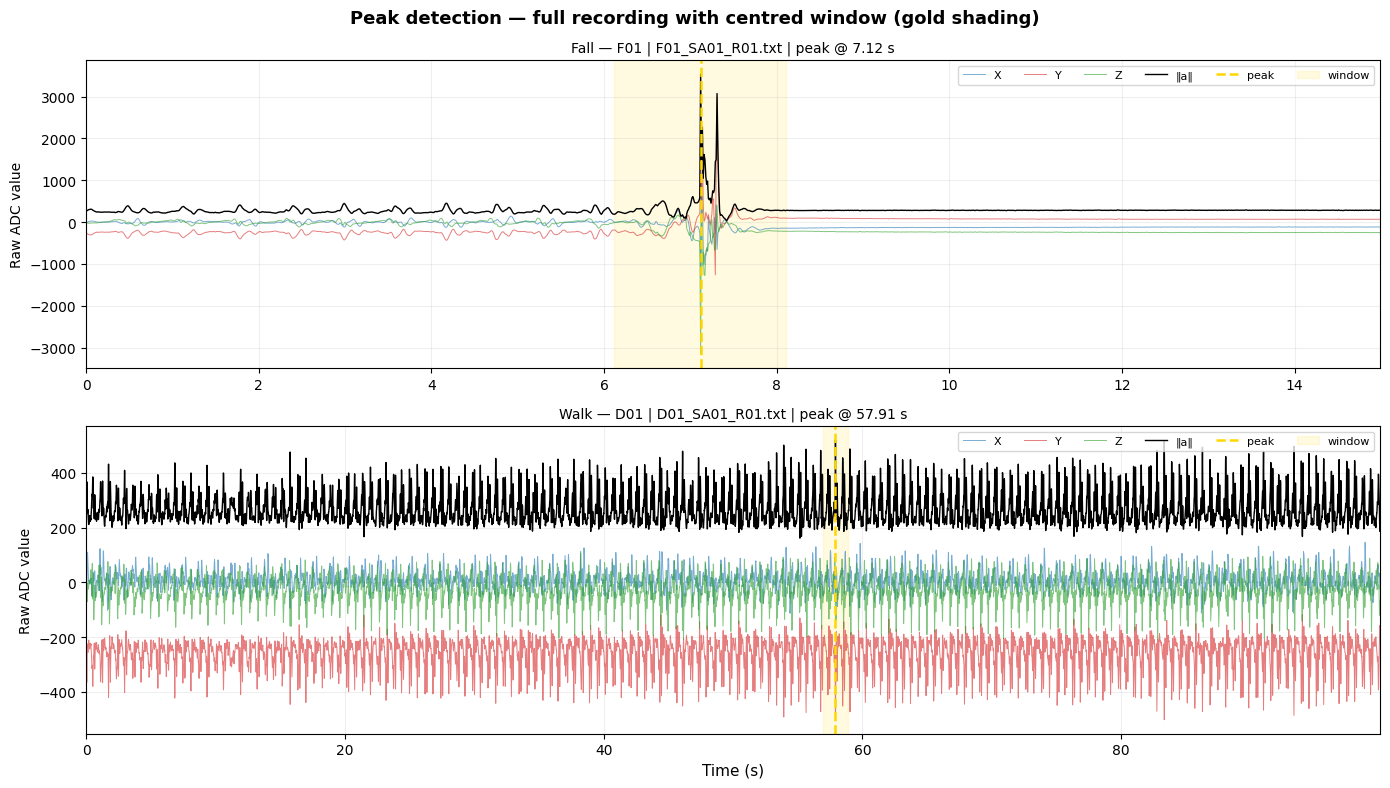

In [21]:
def load_raw_for_vis(label_filter, code_filter=None):
    """Return (acc_raw_ds, peak_idx, fname) for the first matching file found."""
    for subj in sorted(os.listdir(SISFALL_PATH)):
        subj_path = os.path.join(SISFALL_PATH, subj)
        if not os.path.isdir(subj_path):
            continue
        for fname in sorted(os.listdir(subj_path)):
            if not fname.endswith('.txt'):
                continue
            code = fname.split('_')[0]
            if CODE_TO_LABEL.get(code) != label_filter:
                continue
            if code_filter and code != code_filter:
                continue
            raw = parse_sisfall_txt(os.path.join(subj_path, fname))
            if raw is None or len(raw) < WINDOW * 2:
                continue
            raw_ds  = raw[::2]
            acc_raw = raw_ds[:, 0:3]
            _, peak_idx = extract_peak_window(acc_raw, window=WINDOW)
            return acc_raw, peak_idx, fname
    return None, None, None


fig, axes = plt.subplots(2, 1, figsize=(14, 8))
AXIS_COLORS = ['#1f77b4', '#d62728', '#2ca02c']

for ax, (lbl, code_f, title_tag) in zip(axes, [
        (0,  'F01', 'Fall — F01'),
        (2,  'D01', 'Walk — D01'),
]):
    acc_raw, peak_idx, fname = load_raw_for_vis(lbl, code_f)
    if acc_raw is None:
        ax.set_title(f'{title_tag}: no file found')
        continue

    t   = np.arange(len(acc_raw)) / 100.0
    mag = np.linalg.norm(acc_raw, axis=1)

    for i, (axis_name, color) in enumerate(zip(['X', 'Y', 'Z'], AXIS_COLORS)):
        ax.plot(t, acc_raw[:, i], color=color, linewidth=0.7, alpha=0.6, label=axis_name)
    ax.plot(t, mag, color='black', linewidth=1.0, label='\u2016a\u2016')

    ax.axvline(t[peak_idx], color='gold', linewidth=1.8, linestyle='--', label='peak')

    win_start = max(0, min(peak_idx - HALF_WINDOW, len(acc_raw) - WINDOW))
    win_end   = win_start + WINDOW
    ax.axvspan(t[win_start], t[win_end - 1], alpha=0.12, color='gold', label='window')

    ax.set_xlim(0, t[-1])
    ax.set_title(f'{title_tag} | {fname} | peak @ {t[peak_idx]:.2f} s', fontsize=10)
    ax.set_ylabel('Raw ADC value')
    ax.legend(loc='upper right', fontsize=8, ncol=6)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time (s)', fontsize=11)
fig.suptitle('Peak detection — full recording with centred window (gold shading)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4b. Visualise Multi-Peak Extraction on a Non-Fall Recording

Show all non-overlapping peak windows extracted from one Walk recording to illustrate the balancing strategy.

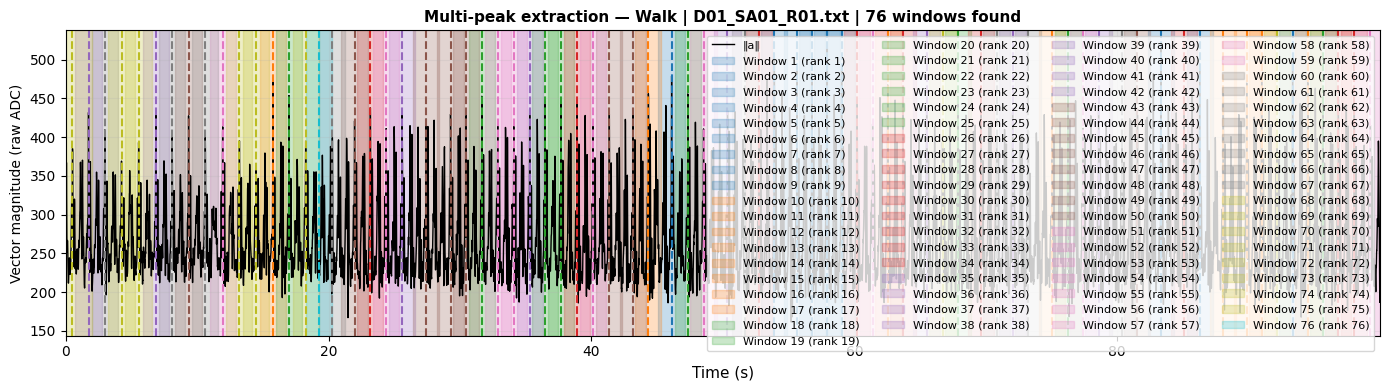

Peak magnitudes: ['519.9', '518.0', '501.1', '496.8', '493.6', '487.4', '486.4', '481.9', '478.9', '478.3', '476.0', '470.4', '469.7', '467.3', '459.6', '456.4', '456.2', '455.7', '453.8', '453.6', '452.7', '452.3', '451.5', '450.0', '449.9', '449.7', '448.6', '448.3', '447.5', '444.6', '443.8', '440.3', '437.7', '436.6', '436.4', '435.9', '434.8', '434.7', '434.0', '431.8', '431.7', '430.9', '429.9', '429.5', '429.5', '428.7', '427.9', '427.5', '423.3', '420.9', '420.6', '418.3', '417.0', '415.4', '413.9', '413.2', '411.4', '410.9', '410.6', '409.3', '408.1', '400.9', '400.8', '399.6', '399.5', '399.3', '397.0', '395.1', '394.5', '393.7', '393.4', '393.1', '385.2', '369.0', '357.6', '240.4']


In [22]:
# Load first Walk recording that yields multiple peaks
demo_acc_raw = None
demo_peaks   = []
demo_fname   = ''

for subj in sorted(os.listdir(SISFALL_PATH)):
    subj_path = os.path.join(SISFALL_PATH, subj)
    if not os.path.isdir(subj_path):
        continue
    for fname in sorted(os.listdir(subj_path)):
        if not fname.endswith('.txt'):
            continue
        code = fname.split('_')[0]
        if code not in ('D01', 'D02'):   # Walk
            continue
        raw = parse_sisfall_txt(os.path.join(subj_path, fname))
        if raw is None or len(raw) < WINDOW * 2:
            continue
        raw_ds  = raw[::2]
        acc_raw = raw_ds[:, 0:3]
        peaks   = extract_all_peaks(acc_raw, window=WINDOW)
        if len(peaks) >= 2:   # pick a recording that has at least 2 peaks
            demo_acc_raw = acc_raw
            demo_peaks   = peaks
            demo_fname   = fname
            break
    if demo_acc_raw is not None:
        break

if demo_acc_raw is None:
    print('No suitable Walk recording found for multi-peak demo.')
else:
    t   = np.arange(len(demo_acc_raw)) / 100.0
    mag = np.linalg.norm(demo_acc_raw, axis=1)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(t, mag, color='black', linewidth=1.0, label='\u2016a\u2016')

    colors_win = plt.cm.tab10(np.linspace(0, 0.9, len(demo_peaks)))
    for rank, ((win_raw, peak_mag), color) in enumerate(zip(demo_peaks, colors_win)):
        # Recompute window start for this peak (need to replay suppression)
        # Instead, find the peak index in the original magnitude that best matches
        # peak_mag (simplest approach: mark at the magnitude value position)
        pass  # handled below

    # Replay extract_all_peaks to recover window positions
    magnitude_copy = mag.copy()
    for rank in range(len(demo_peaks)):
        peak_idx = int(np.argmax(magnitude_copy))
        start    = max(0, min(peak_idx - HALF_WINDOW, len(demo_acc_raw) - WINDOW))
        color    = colors_win[rank]
        ax.axvspan(t[start], t[start + WINDOW - 1], alpha=0.25, color=color,
                   label=f'Window {rank + 1} (rank {rank + 1})')
        ax.axvline(t[peak_idx], color=color, linewidth=1.5, linestyle='--')
        magnitude_copy[start:start + WINDOW] = 0.0

    ax.set_xlim(0, t[-1])
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Vector magnitude (raw ADC)', fontsize=10)
    ax.set_title(
        f'Multi-peak extraction — Walk | {demo_fname} | {len(demo_peaks)} windows found',
        fontsize=11, fontweight='bold'
    )
    ax.legend(loc='upper right', fontsize=8, ncol=4)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
    print(f'Peak magnitudes: {[f"{p[1]:.1f}" for p in demo_peaks]}')

## 5. Visualise Sample Windows

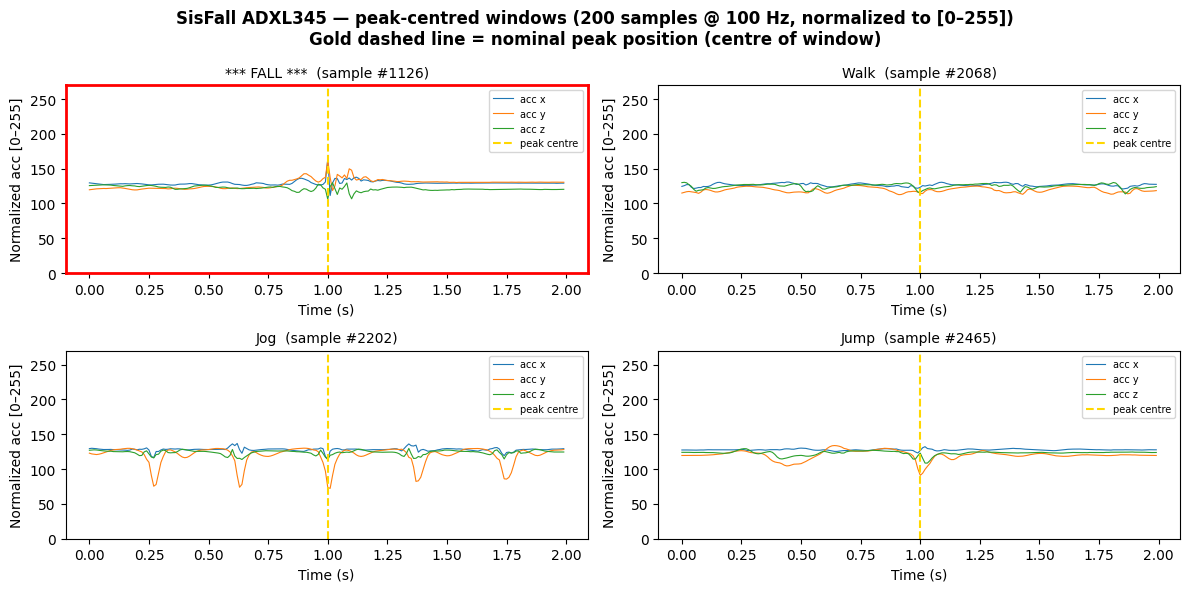

In [23]:
np.random.seed(42)
show_labels = [0, 2, 3, 4]   # Fall, Walk, Jog, Jump

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']

for ax, label in zip(axes.flat, show_labels):
    idxs     = np.where(y == label)[0]
    sample_i = idxs[np.random.randint(len(idxs))]
    acc_data = X_acc[sample_i].reshape(200, 3)
    t        = np.arange(200) / 100.0

    for i, (axis_name, color) in enumerate(zip(['x', 'y', 'z'], colors)):
        ax.plot(t, acc_data[:, i], color=color, linewidth=0.8, label=f'acc {axis_name}')

    ax.axvline(1.0, color='gold', linewidth=1.5, linestyle='--', label='peak centre')

    tag = '*** FALL ***' if label == 0 else CLASS_NAMES[label]
    ax.set_title(f'{tag}  (sample #{sample_i})', fontsize=10)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Normalized acc [0–255]')
    ax.legend(fontsize=7)
    ax.set_ylim(0, 270)

    if label == 0:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2)

fig.suptitle(
    'SisFall ADXL345 — peak-centred windows (200 samples @ 100 Hz, normalized to [0–255])\n'
    'Gold dashed line = nominal peak position (centre of window)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

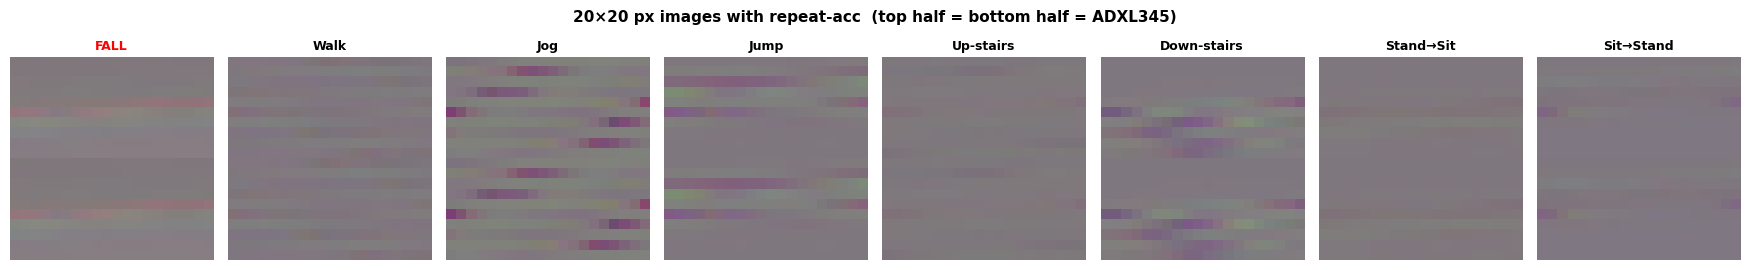

In [24]:
def to_image_repeat(acc_flat):
    """Repeat-acc: copy acc (600 values) to both halves → 20×20×3 image in [0, 1] for display."""
    repeated = np.concatenate([acc_flat, acc_flat])   # (1200,)
    return repeated.reshape(20, 20, 3) / 255.0


np.random.seed(7)
n = len(CLASS_LIST)

fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.8))
for ax, label in zip(axes, CLASS_LIST):
    idxs     = np.where(y == label)[0]
    sample_i = idxs[np.random.randint(len(idxs))]
    img      = to_image_repeat(X_acc[sample_i])
    ax.imshow(img)
    tag = 'FALL' if label == 0 else CLASS_NAMES[label]
    ax.set_title(tag, fontsize=9, color='red' if label == 0 else 'black', fontweight='bold')
    ax.axis('off')

fig.suptitle('20×20 px images with repeat-acc  (top half = bottom half = ADXL345)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Train / Test Split and Save CSVs

Stratified 80/20 split.  
CSVs store the raw 600 acc values — the repeat is applied at inference time.

In [25]:
idx_train, idx_test = train_test_split(
    np.arange(len(X_acc)), test_size=0.2, random_state=42, stratify=y
)

X_acc_train, X_acc_test = X_acc[idx_train], X_acc[idx_test]
y_train,     y_test     = y[idx_train],     y[idx_test]

print(f'Train: {len(X_acc_train)} samples | Test: {len(X_acc_test)} samples')
print()
print(f'{"Class":>12s}  {"Train":>7}  {"Test":>6}')
print('-' * 32)
for lbl in CLASS_LIST:
    print(f'{CLASS_NAMES[lbl]:>12s}  {(y_train == lbl).sum():>7}  {(y_test == lbl).sum():>6}')

Train: 3107 samples | Test: 777 samples

       Class    Train    Test
--------------------------------
        Fall     1438     360
        Walk      239      59
         Jog      239      59
        Jump      238      60
   Up-stairs      238      60
 Down-stairs      238      60
   Stand→Sit      239      59
   Sit→Stand      238      60


In [26]:
col_names = ['label'] + [str(i + 1) for i in range(600)]

train_df = pd.DataFrame(
    np.column_stack([y_train.astype(float), X_acc_train]),
    columns=col_names
)
train_df['label'] = y_train
train_df.to_csv(TRAIN_CSV, index=False)

test_df = pd.DataFrame(
    np.column_stack([y_test.astype(float), X_acc_test]),
    columns=col_names
)
test_df['label'] = y_test
test_df.to_csv(TEST_CSV, index=False)

print(f'Saved  {TRAIN_CSV}  ({len(train_df)} rows, 600 acc values each)')
print(f'Saved  {TEST_CSV}   ({len(test_df)} rows, 600 acc values each)')

Saved  data/sisfall_peak_balanced_train.csv  (3107 rows, 600 acc values each)
Saved  data/sisfall_peak_balanced_test.csv   (777 rows, 600 acc values each)


## 7. Build Model Inputs (Apply Repeat-Acc)

The model expects 1200 values.  
Repeat-acc: `[acc_600, acc_600]` — both halves are identical.

In [27]:
def apply_repeat_acc(X_600):
    """Expand (N, 600) acc array to (N, 1200) by repeating the acc half."""
    return np.hstack([X_600, X_600]).astype(np.float32)


def to_onehot(labels_arr, class_list):
    y_oh = np.zeros((len(labels_arr), len(class_list)), dtype=np.float32)
    for i, lbl in enumerate(labels_arr):
        y_oh[i, class_list.index(lbl)] = 1.0
    return y_oh


X_model_train = apply_repeat_acc(X_acc_train)   # (N_train, 1200)
X_model_test  = apply_repeat_acc(X_acc_test)    # (N_test,  1200)
y_train_oh    = to_onehot(y_train, CLASS_LIST)
y_test_oh     = to_onehot(y_test,  CLASS_LIST)

print(f'Model input shapes — train: {X_model_train.shape}, test: {X_model_test.shape}')
print(f'Value range in model input: [{X_model_train.min():.1f}, {X_model_train.max():.1f}]')

Model input shapes — train: (3107, 1200), test: (777, 1200)
Value range in model input: [0.0, 254.9]


## 8. Build TF Graph and Train

In [28]:
TRAIN_STEPS   = 5000
BATCH_SIZE    = 50
LEARNING_RATE = 0.001

tf.reset_default_graph()

x_ph = tf.placeholder(tf.float32, [None, 1200], name='input')
y_ph = tf.placeholder(tf.float32, [None, CLASS_NUM], name='labels')

logits, keep_prob_ph = cnn_module.fall_net(x_ph)

loss_op = tf.reduce_mean(
    tf.nn.softmax_cross_entropy_with_logits(labels=y_ph, logits=logits)
)
train_op = tf.train.AdamOptimizer(LEARNING_RATE).minimize(loss_op)
correct_op = tf.equal(tf.argmax(logits, 1), tf.argmax(y_ph, 1))
acc_op = tf.reduce_mean(tf.cast(correct_op, tf.float32))
probs_op = tf.nn.softmax(logits)

saver = tf.train.Saver()
sess  = tf.Session()
sess.run(tf.global_variables_initializer())

print(f'Graph built.  Training on {len(X_model_train)} samples for {TRAIN_STEPS} steps...')

Graph built.  Training on 3107 samples for 5000 steps...


In [29]:
n_train = len(X_model_train)
perm = np.random.permutation(n_train)
ptr  = 0

log_steps, log_loss, log_acc = [], [], []

for step in range(1, TRAIN_STEPS + 1):
    if ptr + BATCH_SIZE > n_train:
        perm = np.random.permutation(n_train)
        ptr  = 0

    batch_idx = perm[ptr:ptr + BATCH_SIZE]
    ptr += BATCH_SIZE

    feed = {x_ph: X_model_train[batch_idx],
            y_ph: y_train_oh[batch_idx],
            keep_prob_ph: 0.5}
    _, loss_val = sess.run([train_op, loss_op], feed_dict=feed)

    if step % 500 == 0:
        acc_val = acc_op.eval(session=sess,
                              feed_dict={x_ph: X_model_train[batch_idx],
                                         y_ph: y_train_oh[batch_idx],
                                         keep_prob_ph: 1.0})
        log_steps.append(step)
        log_loss.append(loss_val)
        log_acc.append(acc_val)
        print(f'Step {step:5d}  |  loss = {loss_val:.4f}  |  batch acc = {acc_val:.4f}')

save_path = saver.save(sess, MODEL_SAVE_PATH)
print(f'\nModel saved to {save_path}')

Step   500  |  loss = 0.0435  |  batch acc = 1.0000
Step  1000  |  loss = 0.0189  |  batch acc = 1.0000
Step  1500  |  loss = 0.0084  |  batch acc = 1.0000
Step  2000  |  loss = 0.0116  |  batch acc = 1.0000
Step  2500  |  loss = 0.0401  |  batch acc = 1.0000
Step  3000  |  loss = 0.0005  |  batch acc = 1.0000
Step  3500  |  loss = 0.0035  |  batch acc = 1.0000
Step  4000  |  loss = 0.0001  |  batch acc = 1.0000
Step  4500  |  loss = 0.0002  |  batch acc = 1.0000
Step  5000  |  loss = 0.0288  |  batch acc = 1.0000

Model saved to model/sisfall_peak_balanced_model.ckpt


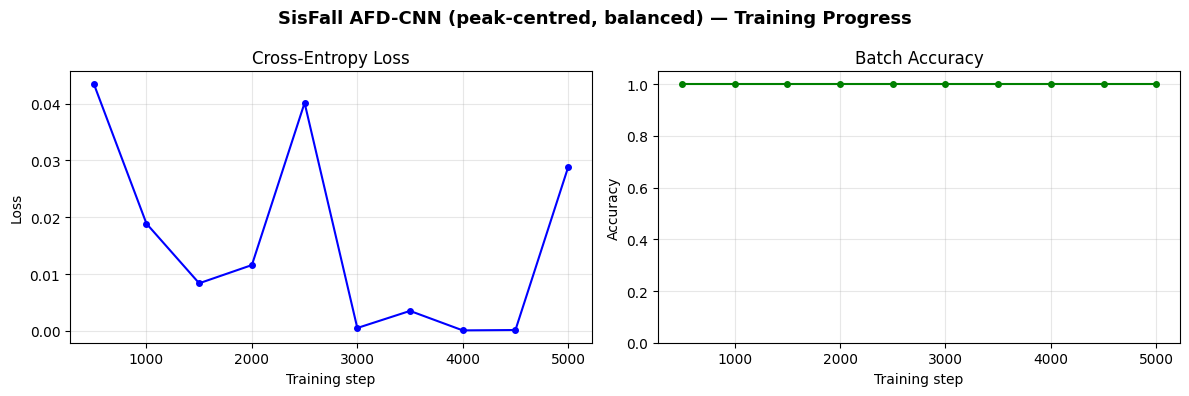

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(log_steps, log_loss, 'b-o', markersize=4)
ax1.set_title('Cross-Entropy Loss')
ax1.set_xlabel('Training step')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(log_steps, log_acc, 'g-o', markersize=4)
ax2.set_title('Batch Accuracy')
ax2.set_xlabel('Training step')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

fig.suptitle('SisFall AFD-CNN (peak-centred, balanced) — Training Progress',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Evaluate on Train and Test Sets

In [31]:
def run_inference(X):
    """Run model on (N, 1200) array in batches; return pred_labels (N,) and probs (N, 8)."""
    EVAL_BATCH = 256
    all_probs = []
    for start in range(0, len(X), EVAL_BATCH):
        p = sess.run(probs_op, feed_dict={x_ph: X[start:start + EVAL_BATCH], keep_prob_ph: 1.0})
        all_probs.append(p)
    all_probs   = np.vstack(all_probs)
    pred_idx    = np.argmax(all_probs, axis=1)
    pred_labels = np.array([CLASS_LIST[i] for i in pred_idx])
    return pred_labels, all_probs


for split_name, X_split, y_split in [
        ('Train', X_model_train, y_train),
        ('Test',  X_model_test,  y_test)]:

    pred_labels, _ = run_inference(X_split)
    overall = np.mean(pred_labels == y_split)

    print(f'=== {split_name} set ({len(y_split)} samples) ===')
    print(f'Overall accuracy: {overall:.4f}  ({overall:.2%})')
    print(f'{"Class":>12s}  {"N":>5}  {"Sensitivity":>12}  {"Specificity":>12}')
    print('-' * 48)

    for lbl in CLASS_LIST:
        acc, sens, spec = cnn_module.evaluate(pred_labels, y_split, lbl)
        n_cls = int((y_split == lbl).sum())
        print(f'{CLASS_NAMES[lbl]:>12s}  {n_cls:>5}  {sens:>12.4f}  {spec:>12.4f}')
    print()

=== Train set (3107 samples) ===
Overall accuracy: 0.9987  (99.87%)
       Class      N   Sensitivity   Specificity
------------------------------------------------
        Fall   1438        0.9986        1.0000
        Walk    239        0.9958        1.0000
         Jog    239        1.0000        1.0000
        Jump    238        1.0000        1.0000
   Up-stairs    238        1.0000        0.9993
 Down-stairs    238        1.0000        1.0000
   Stand→Sit    239        1.0000        0.9993
   Sit→Stand    238        0.9958        1.0000

=== Test set (777 samples) ===
Overall accuracy: 0.9704  (97.04%)
       Class      N   Sensitivity   Specificity
------------------------------------------------
        Fall    360        0.9917        0.9976
        Walk     59        0.9492        0.9986
         Jog     59        0.9661        1.0000
        Jump     60        0.9833        0.9972
   Up-stairs     60        0.9833        0.9944
 Down-stairs     60        0.9833        0.9972

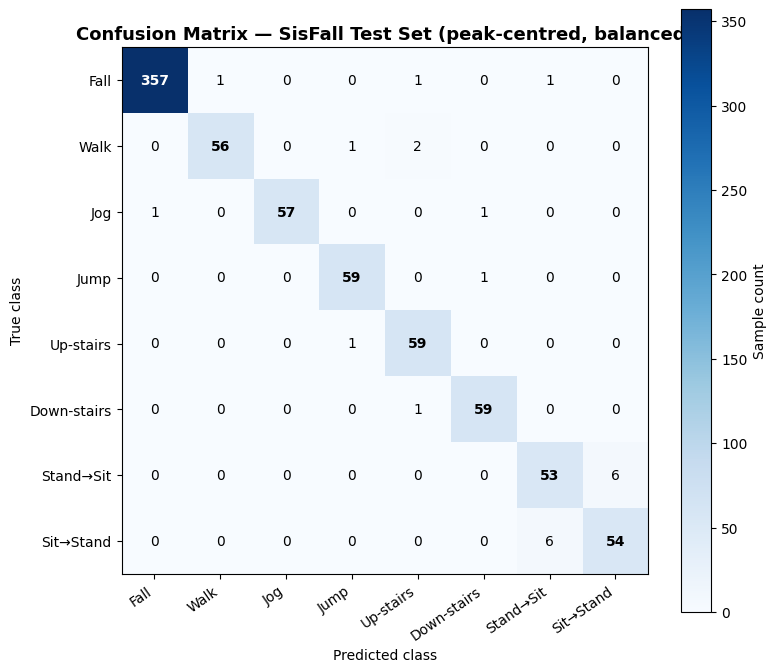

Training complete. Session closed.
Checkpoint saved at: model/sisfall_peak_balanced_model.ckpt
Test CSV saved at:   data/sisfall_peak_balanced_test.csv


In [32]:
pred_test, _ = run_inference(X_model_test)
label_names  = [CLASS_NAMES[l] for l in CLASS_LIST]
cm = confusion_matrix(y_test, pred_test, labels=CLASS_LIST)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax, label='Sample count')

ax.set_xticks(range(len(CLASS_LIST)))
ax.set_yticks(range(len(CLASS_LIST)))
ax.set_xticklabels(label_names, rotation=35, ha='right')
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_title(
    'Confusion Matrix \u2014 SisFall Test Set (peak-centred, balanced)',
    fontsize=13, fontweight='bold'
)

for i in range(len(CLASS_LIST)):
    for j in range(len(CLASS_LIST)):
        val    = cm[i, j]
        color  = 'white' if val > cm.max() / 2 else 'black'
        weight = 'bold' if i == j else 'normal'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=10, color=color, fontweight=weight)

plt.tight_layout()
plt.show()

sess.close()
print('Training complete. Session closed.')
print(f'Checkpoint saved at: {MODEL_SAVE_PATH}')
print(f'Test CSV saved at:   {TEST_CSV}')